# Data Understanding: Open Transaction Data
**3.4.2 Data Understanding**

This notebook performs a comprehensive data understanding analysis on the **Open Transaction Data** dataset, covering property transaction records in Malaysia from 2021 to 2025. The analysis includes variable description, observation summaries, distribution visualizations, and key insights.

## 1. Import Libraries and Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
import os
os.makedirs('images/open_transaction', exist_ok=True)


In [4]:
# Load dataset
file_path = '../property data/Open Transaction Data.xlsx'

# ensure path exists
import os
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Data file not found: {file_path}")
df_raw = pd.read_excel(file_path)

print(f'Dataset loaded successfully.')
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')

Dataset loaded successfully.
Shape: 416,627 rows x 13 columns


## 2. Initial Inspection

In [5]:
print('=== Column Names ===')
for i, col in enumerate(df_raw.columns):
    print(f'  [{i}] {repr(col)}')

print('\n=== First 5 Rows ===')
df_raw.head()

=== Column Names ===
  [0] 'Property Type'
  [1] 'District'
  [2] 'Mukim'
  [3] 'Scheme Name/Area'
  [4] 'Road Name'
  [5] 'Month, Year of Transaction Date'
  [6] 'Tenure'
  [7] 'Land/Parcel Area'
  [8] 'Unit'
  [9] 'Main Floor Area'
  [10] 'Unit        '
  [11] 'Unit Level'
  [12] 'Transaction Price  '

=== First 5 Rows ===


,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.0,sq.m,106,sq.m,,"RM470,000.00"
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.0,sq.m,67,sq.m,,"RM483,000.00"
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,sq.m,118,sq.m,,"RM359,000.00"
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,sq.m,118,sq.m,,"RM435,000.00"
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,297.0,sq.m,118,sq.m,,"RM373,000.00"


In [6]:
print('=== Data Types ===')
print(df_raw.dtypes)
print('\n=== Basic Info ===')
df_raw.info()

=== Data Types ===
Property Type                              object
District                                   object
Mukim                                      object
Scheme Name/Area                           object
Road Name                                  object
Month, Year of Transaction Date    datetime64[ns]
Tenure                                     object
Land/Parcel Area                          float64
Unit                                       object
Main Floor Area                            object
Unit                                       object
Unit Level                                 object
Transaction Price                          object
dtype: object

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416627 entries, 0 to 416626
Data columns (total 13 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Property Type                    416627 n

## 3. Data Preprocessing (for Understanding)

Section 3 is where we get the raw spreadsheet into a form that’s usable for the
rest of the notebook.  
In prose it does the following:

* make a working copy of `df_raw` so the original stays untouched,
* rename awkward column labels (`'Transaction Price  '` → `'Transaction Price'`,
    `'Month, Year of Transaction Date'` → `'Transaction Date'`),
* clean and convert the price field – strip “RM” and commas and cast to float in
    a new `Transaction Price (RM)` column,
* parse the transaction date string into a `datetime` and pull out `Year` and
    `Month`,
* coerce the “Main Floor Area” column to numeric (non‑numeric entries become
    NaN),
* finally, report the shape of the cleaned dataframe.

These preprocessing steps ensure the dataset has consistent names and
appropriate dtypes (numerical prices/areas, datetime dates, etc.) so that
subsequent exploration, summaries and plots work correctly.

In [7]:
# Work on a clean copy
df = df_raw.copy()

In [8]:
# Rename columns for ease of use
df.rename(columns={
    'Transaction Price  ': 'Transaction Price',
    'Month, Year of Transaction Date': 'Transaction Date'
}, inplace=True)


In [9]:
# Drop columns whose name (stripped) is 'Unit' — handles 'Unit' and 'Unit        ' and duplicates by position
unit_col_indices = [i for i, c in enumerate(df.columns) if isinstance(c, str) and c.strip() == 'Unit']
if unit_col_indices:
    dropped_cols = list(df.columns[unit_col_indices])
    df.drop(df.columns[unit_col_indices], axis=1, inplace=True)
    print(f"Dropped {len(unit_col_indices)} column(s) at positions {unit_col_indices}: {dropped_cols}. New shape: {df.shape}")
else:
    print("No 'Unit' columns found.")

Dropped 2 column(s) at positions [8, 10]: ['Unit', 'Unit        ']. New shape: (416627, 11)


In [10]:

# Parse Transaction Price: strip 'RM' and commas -> float
df['Transaction Price (RM)'] = (
    df['Transaction Price']
    .str.replace('RM', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

In [11]:

# Parse date
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month


In [12]:

# Coerce Main Floor Area to numeric
df['Main Floor Area'] = pd.to_numeric(df['Main Floor Area'], errors='coerce')


In [13]:
print('Preprocessing complete.')
df.drop('Transaction Price', axis=1, inplace=True)
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df

Preprocessing complete.
Final shape: 416,627 rows x 13 columns


,Property Type,District,Mukim,Scheme Name/Area,Road Name,Transaction Date,Tenure,Land/Parcel Area,Main Floor Area,Unit Level,Transaction Price (RM),Year,Month
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.00,106.0,,470000.0,2024,3
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.00,67.0,,483000.0,2023,5
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.00,118.0,,359000.0,2021,4
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.00,118.0,,435000.0,2021,4
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,297.00,118.0,,373000.0,2021,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
416622,Town House,Timur Laut,Tanjung Tokong,TANJONG VILLA,,2022-08-01,Freehold,103.00,NaN,1,850000.0,2022,8
416623,Town House,Timur Laut,Tanjung Tokong,TANJONG VILLA,,2024-02-01,Freehold,174.00,NaN,1,1110000.0,2024,2
416624,Town House,Timur Laut,Tanjung Tokong,VILLA BUNGA TELANG,,2023-07-01,Freehold,83.00,NaN,3,540000.0,2023,7
416625,Town House,Timur Laut,Tanjung Tokong,VILLA BUNGA TELANG,,2025-01-01,Freehold,83.00,NaN,3,525000.0,2025,1


---
## 4. Variables – Description of Each Variable

The table below describes all 13 original variables in the dataset.

In [14]:
print('=== Adjusted Data Types ===')
print(df.dtypes)
print(f'Dataset has {df.shape[1]} columns')

=== Adjusted Data Types ===
Property Type                     object
District                          object
Mukim                             object
Scheme Name/Area                  object
Road Name                         object
Transaction Date          datetime64[ns]
Tenure                            object
Land/Parcel Area                 float64
Main Floor Area                  float64
Unit Level                        object
Transaction Price (RM)           float64
Year                               int32
Month                              int32
dtype: object
Dataset has 13 columns


In [15]:

print('=== Adjusted Data Types ===')
print(df.dtypes)
print(f'Dataset has {df.shape[1]} columns')


=== Adjusted Data Types ===
Property Type                     object
District                          object
Mukim                             object
Scheme Name/Area                  object
Road Name                         object
Transaction Date          datetime64[ns]
Tenure                            object
Land/Parcel Area                 float64
Main Floor Area                  float64
Unit Level                        object
Transaction Price (RM)           float64
Year                               int32
Month                              int32
dtype: object
Dataset has 13 columns


---
## 5. Observations – Dataset Overview

In [16]:
# Summary statistics for each variable
summary_stats = df.describe(include='all').T

# Add additional statistics
summary_stats['Missing Count'] = df.isnull().sum()
summary_stats['Missing (%)'] = (df.isnull().sum() / len(df) * 100).round(2)
summary_stats['Data Type'] = df.dtypes

# Reorder columns for clarity
summary_stats = summary_stats[['Data Type', 'count', 'Missing Count', 'Missing (%)', 'mean', 'min', '25%', '50%', '75%', 'max', 'std']]

print('='*120)
print('COMPREHENSIVE SUMMARY STATISTICS FOR ALL VARIABLES')
print('='*120)
print(summary_stats.to_string())

print('\n' + '='*120)
print('KEY INSIGHTS')
print('='*120)
for col in df.columns:
    if df[col].dtype in ['int32', 'int64', 'float64']:
        print(f'\n{col}:')
        print(f'  Min: {df[col].min():.2f} | Max: {df[col].max():.2f} | Mean: {df[col].mean():.2f} | Median: {df[col].median():.2f}')

COMPREHENSIVE SUMMARY STATISTICS FOR ALL VARIABLES
                             Data Type     count  Missing Count  Missing (%)                           mean                  min                  25%                  50%                  75%                  max            std
Property Type                   object    416627              0         0.00                            NaN                  NaN                  NaN                  NaN                  NaN                  NaN            NaN
District                        object    416627              0         0.00                            NaN                  NaN                  NaN                  NaN                  NaN                  NaN            NaN
Mukim                           object    416627              0         0.00                            NaN                  NaN                  NaN                  NaN                  NaN                  NaN            NaN
Scheme Name/Area                objec

### 5.2 Descriptive Statistics – Numerical Variables

In [17]:
num_cols = ['Land/Parcel Area', 'Main Floor Area', 'Transaction Price (RM)']
df[num_cols].describe().round(2)

,Land/Parcel Area,Main Floor Area,Transaction Price (RM)
count,416626.00,308887.00,416627.00
mean,192.21,127.21,499460.14
std,3997.76,302.68,556970.49
min,8.27,0.00,5000.00
25%,100.89,80.00,250000.00
50%,130.06,110.00,371000.00
75%,190.00,157.00,570000.00
max,1788888.00,159390.00,38000000.00


### 5.3 Descriptive Statistics – Categorical Variables

In [ ]:
cat_cols = ['Property Type', 'District', 'Tenure', 'Mukim', 'Scheme Name/Area', 'Road Name']
for col in cat_cols:
    print(f'--- {col} ({df[col].nunique()} unique values) ---')
    print(df[col].value_counts().head(10).to_string())
    print()

--- Property Type (11 unique values) ---
Property Type
2 - 2 1/2 Storey Terraced         118722
1 - 1 1/2 Storey Terraced          93697
Condominium/Apartment              65780
Low-Cost House                     28351
1 - 1 1/2 Storey Semi-Detached     22030
Low-Cost Flat                      21190
Detached                           18939
2 - 2 1/2 Storey Semi-Detached     18071
Flat                               16504
Cluster House                       9092

--- District (127 unique values) ---
District
Johor Bahru     46111
Petaling        33861
Kuala Lumpur    26365
Hulu Langat     22984
Kinta           19155
Klang           18633
Seremban        17492
Gombak          12386
Timur Laut      11504
Kuala Muda      10948

--- Tenure (2 unique values) ---
Tenure
Freehold     276848
Leasehold    139779

--- Mukim (1343 unique values) ---
Mukim
Pulai                 17442
Ulu Kinta             14121
Plentong              13903
Tebrau                11773
Kelang                10921
Mukim

### 5.4 Categorical Variables – Detailed Findings

#### Property Type Distribution

The dataset contains **11 distinct property types**, with a clear market concentration in terraced housing. The 2–2½ Storey Terraced category dominates with **118,722 transactions (28.5%)**, followed closely by 1–1½ Storey Terraced at **93,697 transactions (22.5%)**. Together, terraced houses account for over half of all transactions (**212,419; ~51.0%**), reflecting the enduring popularity and affordability of this housing segment in Malaysia.

Condominiums and apartments form the second-largest market segment with **65,780 transactions (15.8%)**, indicating significant demand for high-rise residential units, particularly in urban centres. Low-cost housing options—Low-Cost Houses and Low-Cost Flats—comprise **49,541 transactions combined (11.9%)**, serving the affordable housing market segment.

Detached houses and semi-detached properties represent a more limited market share. The 1–1½ Storey Semi-Detached and 2–2½ Storey Semi-Detached categories combined account for **40,101 transactions (9.6%)**, while standalone Detached houses represent **18,939 transactions (4.5%)**. Regular Flats account for **16,504 transactions (4.0%)**, with Cluster Houses at **9,092 transactions (2.2%)** and Town Houses forming the smallest category at approximately **4,251 transactions (1.0%)**.

#### District Distribution

The market is **geographically concentrated, with 127 unique districts** but heavily skewed toward the top performers. The **top 5 districts account for 148,476 transactions (35.6%)** of the total volume, indicating strong market concentration in key urban and semi-urban areas.

**Johor Bahru leads significantly** with **46,111 transactions (11.1%)**, the highest of any district in the dataset. This is followed by **Petaling (33,861 transactions, 8.1%)** and **Kuala Lumpur (26,365 transactions, 6.3%)**, both major business and residential hubs in the Klang Valley. The top three districts collectively account for **106,337 transactions (25.5%)** of all activity.

Secondary markets include **Hulu Langat (22,984 transactions)**, **Kinta (19,155 transactions)**, **Klang (18,633 transactions)**, and **Seremban (17,492 transactions)**, all significant urban or semi-urban centres. The remaining **122 districts** share the remainder of transactions, with most recording substantially lower activity, indicating that the Malaysian property market is dominated by a small number of high-transaction districts, likely reflecting population density and economic activity concentration.

#### Tenure Distribution

The dataset shows a **clear preference for freehold ownership**, with **276,848 freehold transactions (66.5%)** compared to **139,779 leasehold transactions (33.5%)**. This **approximately 2:1 ratio** indicates that freehold properties are nearly twice as common in the market, reflecting buyer preference for properties with full land ownership and perpetual tenure rights.

Freehold properties offer buyers indefinite ownership and greater long-term value security, making them more attractive in Malaysia's property market. In contrast, leasehold properties—which involve time-limited land rights—appeal to a more niche segment, often comprising high-rise units in urban developments where leasehold structures are standard.


---
## 6. Histograms and Visualizations
### 6.1 Distribution of Transaction Price

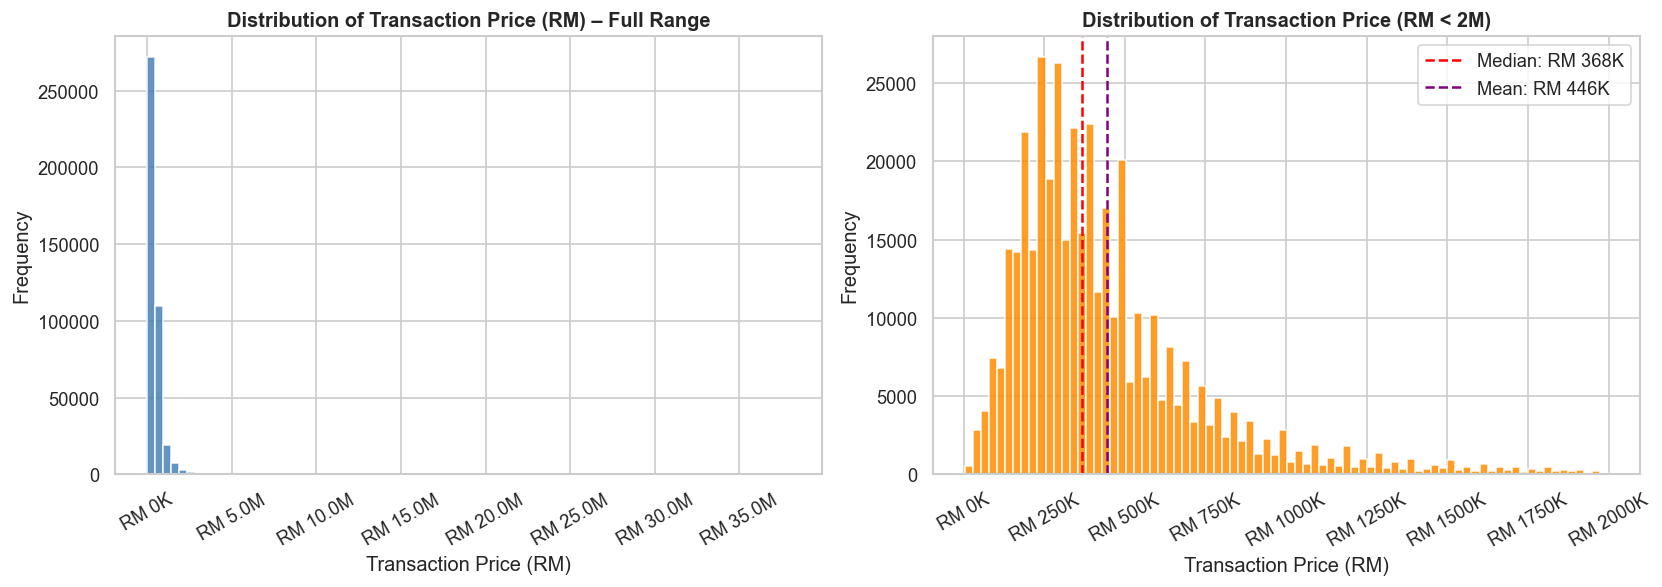

Observation: Transaction prices are right-skewed. Most transactions fall between RM 200K–600K, with a median of RM 368K


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(df['Transaction Price (RM)'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Transaction Price (RM) – Full Range', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transaction Price (RM)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e6:.1f}M' if x>=1e6 else f'RM {x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=30)

# Clipped for readability (< 2M)
clip = df[df['Transaction Price (RM)'] < 2_000_000]['Transaction Price (RM)']
axes[1].hist(clip, bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(clip.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: RM {clip.median()/1e3:.0f}K')
axes[1].axvline(clip.mean(), color='purple', linestyle='--', linewidth=1.5, label=f'Mean: RM {clip.mean()/1e3:.0f}K')
axes[1].set_title('Distribution of Transaction Price (RM < 2M)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Transaction Price (RM)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e3:.0f}K'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.savefig('images/open_transaction/hist_transaction_price.png', bbox_inches='tight')
plt.show()
print(f'Observation: Transaction prices are right-skewed. Most transactions fall between RM 200K–600K, with a median of RM {clip.median()/1e3:.0f}K')

### 6.2 Distribution of Land/Parcel Area

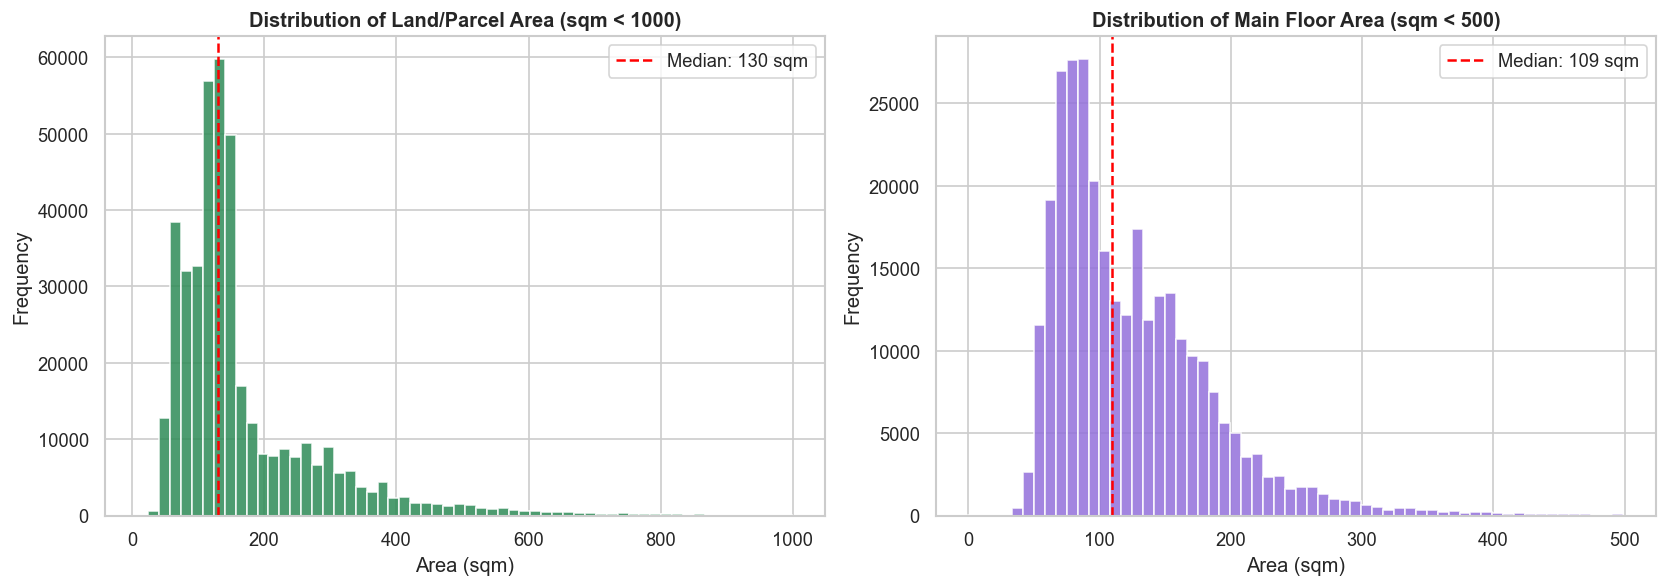

Observation: Most landed properties have parcel areas of 100–200 sqm. Main floor areas peak around 80–160 sqm.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

land_clipped = df[df['Land/Parcel Area'] < 1000]['Land/Parcel Area']

axes[0].hist(land_clipped, bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[0].axvline(land_clipped.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {land_clipped.median():.0f} sqm')
axes[0].set_title('Distribution of Land/Parcel Area (sqm < 1000)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Area (sqm)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

floor_data = df['Main Floor Area'].dropna()
floor_clipped = floor_data[floor_data < 500]
axes[1].hist(floor_clipped, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].axvline(floor_clipped.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {floor_clipped.median():.0f} sqm')
axes[1].set_title('Distribution of Main Floor Area (sqm < 500)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Area (sqm)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/open_transaction/hist_areas.png', bbox_inches='tight')
plt.show()
print('Observation: Most landed properties have parcel areas of 100–200 sqm. Main floor areas peak around 80–160 sqm.')

### 6.3 Transactions by Property Type

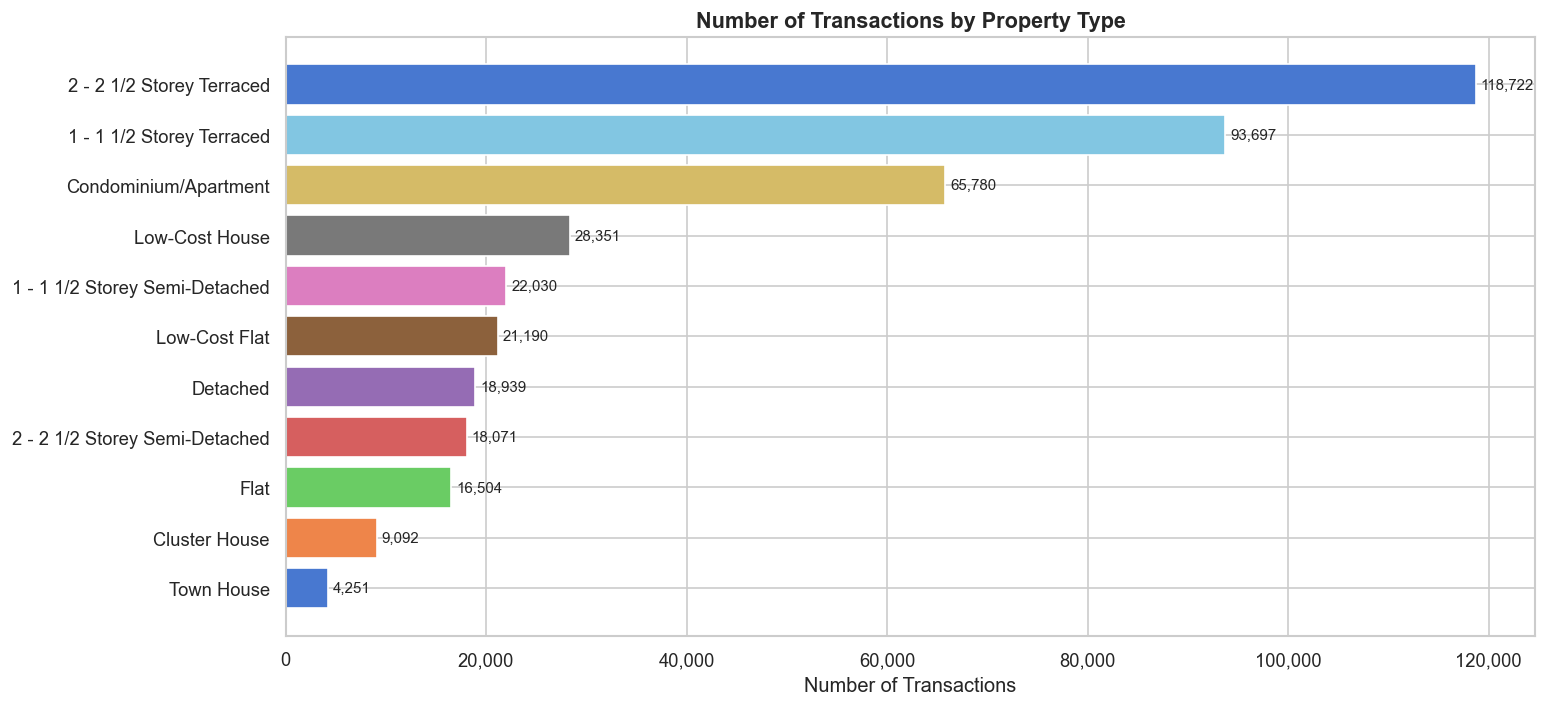

Observation: 2 - 2 1/2 Storey Terraced is the most transacted property type (118,722), followed by 1 - 1 1/2 Storey Terraced (93,697) and Condominium/Apartment (65,780).


In [ ]:
prop_counts = df['Property Type'].value_counts()

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(prop_counts.index[::-1], prop_counts.values[::-1], color=sns.color_palette('muted', len(prop_counts)))

for bar, val in zip(bars, prop_counts.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Number of Transactions by Property Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Transactions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('images/open_transaction/bar_property_type.png', bbox_inches='tight')
plt.show()
print(f'Observation: {prop_counts.index[0]} is the most transacted property type ({prop_counts.values[0]:,}), followed by {prop_counts.index[1]} ({prop_counts.values[1]:,}) and {prop_counts.index[2]} ({prop_counts.values[2]:,}).')

### 6.4 Transactions by District (Top 15)

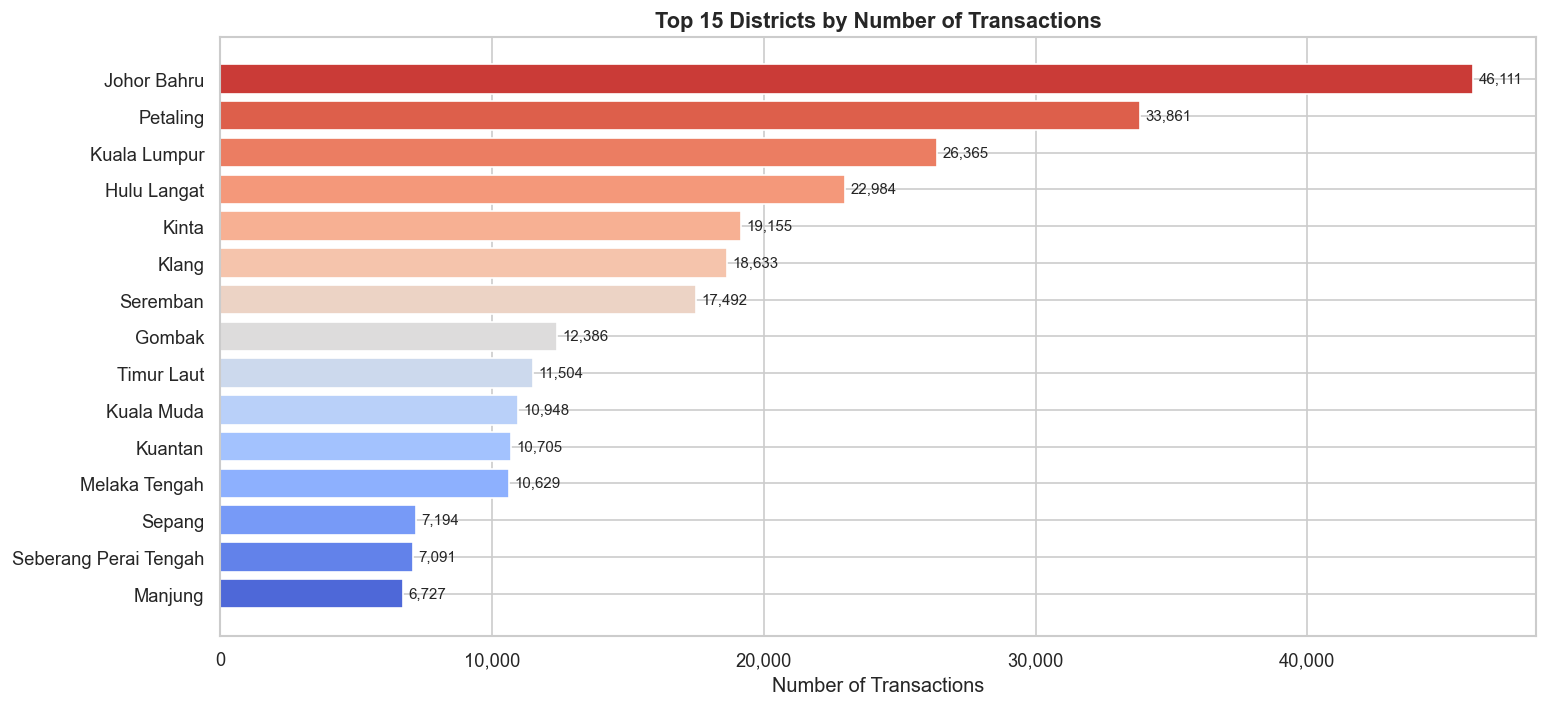

Observation: Johor Bahru leads with 46,111 transactions, followed by Petaling (33,861) and Kuala Lumpur (26,365).


In [ ]:
top15 = df['District'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette('coolwarm', 15)
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 15 Districts by Number of Transactions', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Transactions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('images/open_transaction/bar_district.png', bbox_inches='tight')
plt.show()
print(f'Observation: {top15.index[0]} leads with {top15.values[0]:,} transactions, followed by {top15.index[1]} ({top15.values[1]:,}) and {top15.index[2]} ({top15.values[2]:,}).')

### 6.5 Tenure Distribution (Freehold vs Leasehold)

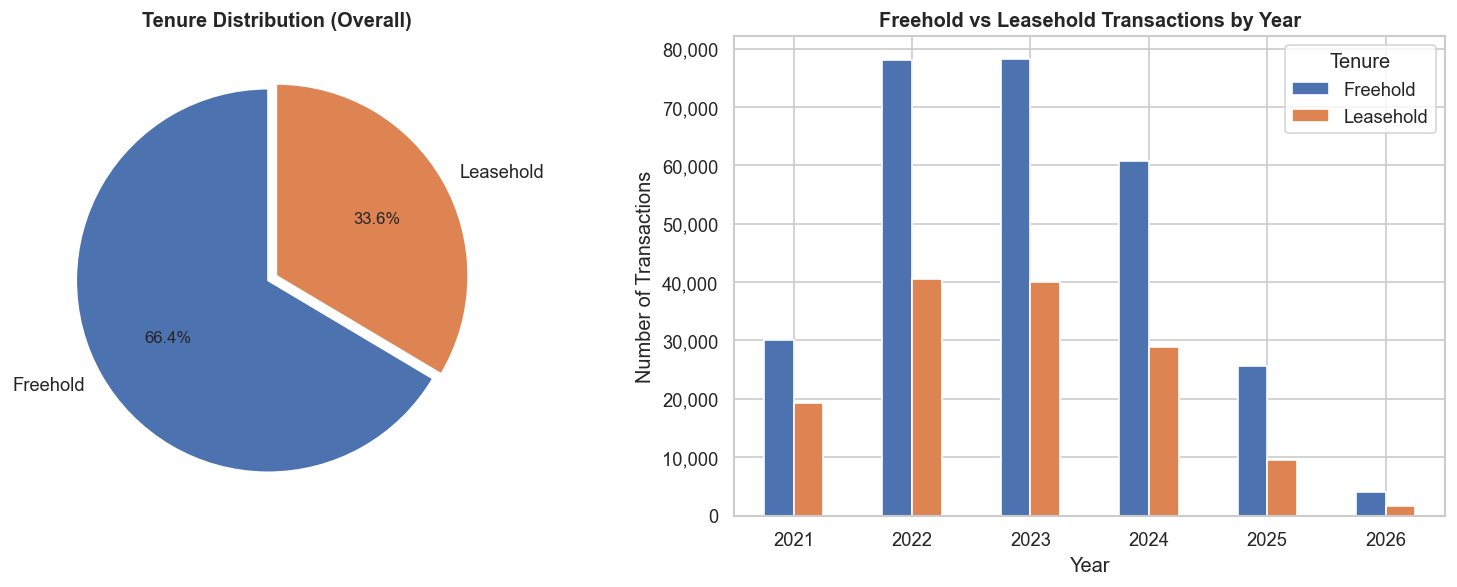

Observation: 66.4% of all transactions are Freehold properties, outnumbering Leasehold (33.6%) consistently across all years.


In [ ]:
tenure_counts = df['Tenure'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(
    tenure_counts.values,
    labels=tenure_counts.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    explode=(0.05, 0)
)
axes[0].set_title('Tenure Distribution (Overall)', fontsize=12, fontweight='bold')

# By year
tenure_year = df.groupby(['Year', 'Tenure']).size().unstack(fill_value=0)
tenure_year.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[1].set_title('Freehold vs Leasehold Transactions by Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Transactions')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Tenure')

plt.tight_layout()
plt.savefig('images/open_transaction/pie_tenure.png', bbox_inches='tight')
plt.show()
print(f'Observation: {tenure_counts.values[0]/tenure_counts.sum()*100:.1f}% of all transactions are {tenure_counts.index[0]} properties, outnumbering {tenure_counts.index[1]} ({tenure_counts.values[1]/tenure_counts.sum()*100:.1f}%) consistently across all years.')

### 6.6 Transaction Volume Over Time (Monthly Trend)

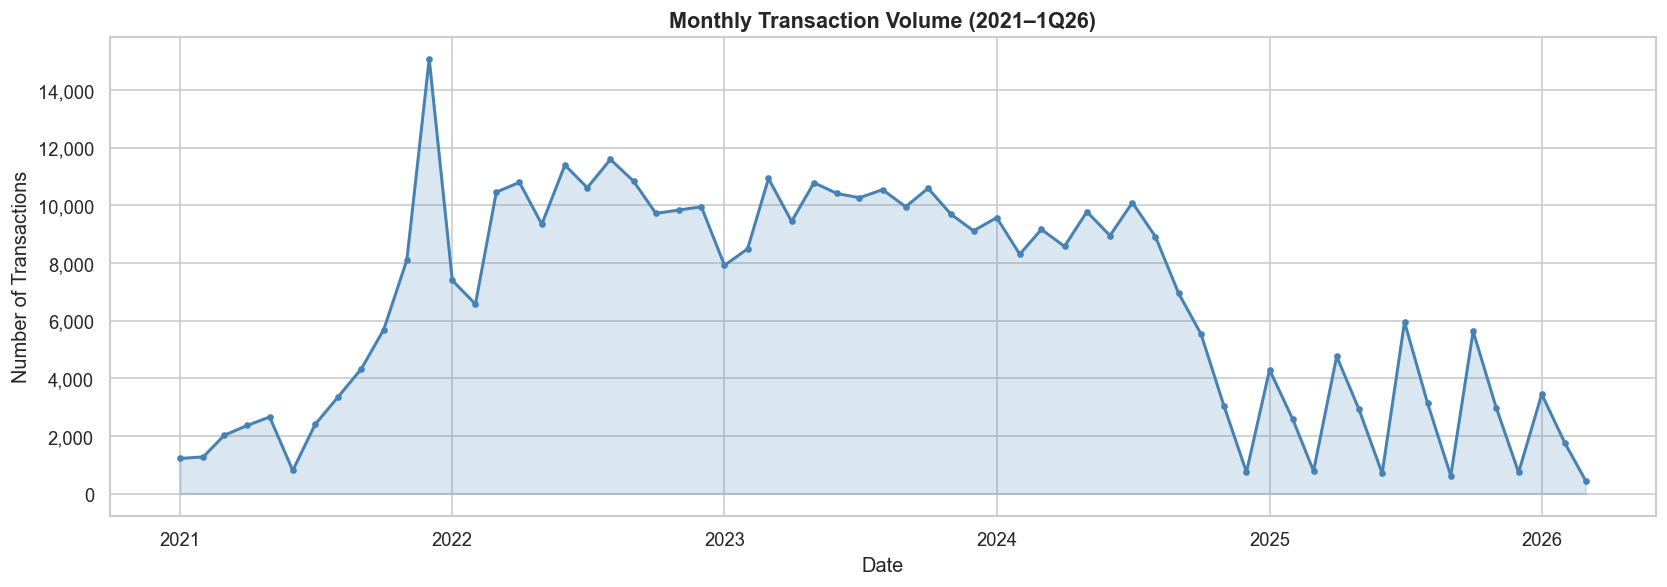

Observation: Transaction volume shows a peak around 2022-2023, with a gradual tapering in 2024-1Q26.


In [ ]:
monthly = df.groupby('Transaction Date').size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Transaction Date'], monthly['Count'], color='steelblue', linewidth=1.8, marker='o', markersize=3)
ax.fill_between(monthly['Transaction Date'], monthly['Count'], alpha=0.2, color='steelblue')
ax.set_title('Monthly Transaction Volume (2021–1Q26)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('images/open_transaction/line_monthly_volume.png', bbox_inches='tight')
plt.show()
print('Observation: Transaction volume shows a peak around 2022-2023, with a gradual tapering in 2024-1Q26.')

### 6.7 Annual Transaction Count by Year

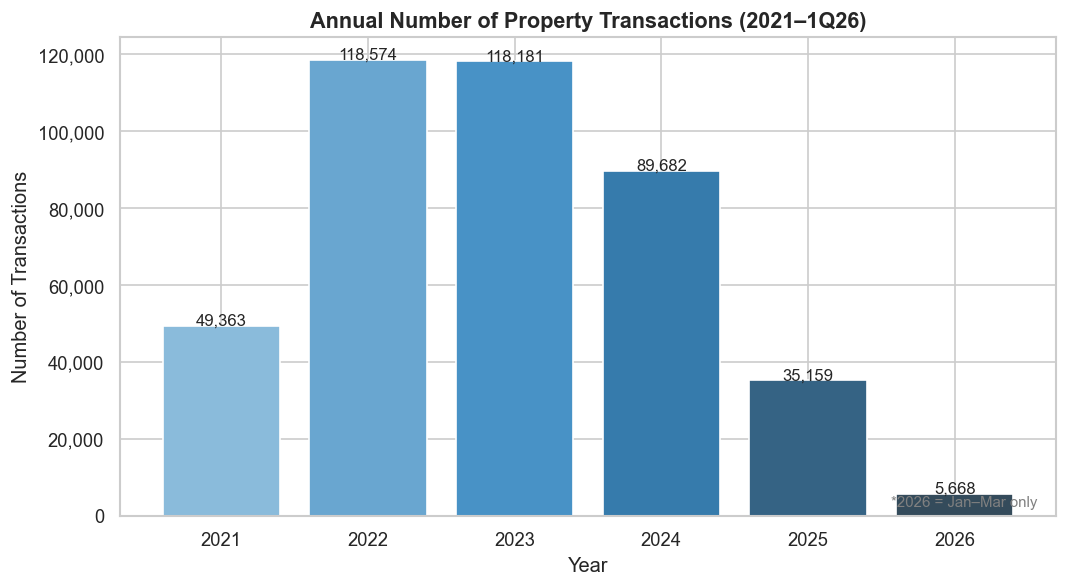

Observation: 2022 and 2021 recorded the highest volumes (~118,574 transactions each), indicating a post-pandemic property market rebound.


In [ ]:
yearly = df['Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(yearly.index.astype(str), yearly.values, color=sns.color_palette('Blues_d', len(yearly)), edgecolor='white')
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, f'{val:,}', ha='center', fontsize=10)

ax.set_title('Annual Number of Property Transactions (2021–1Q26)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.annotate('*2026 = Jan–Mar only', xy=(0.98, 0.02), xycoords='axes fraction', ha='right', fontsize=9, color='grey')
plt.tight_layout()
plt.savefig('images/open_transaction/bar_annual_volume.png', bbox_inches='tight')
plt.show()
print(f'Observation: {yearly.index[yearly.argmax()]} and {yearly.index[yearly.argmax() - 1]} recorded the highest volumes (~{yearly.max():,} transactions each), indicating a post-pandemic property market rebound.')

### 6.8 Median Transaction Price by Property Type

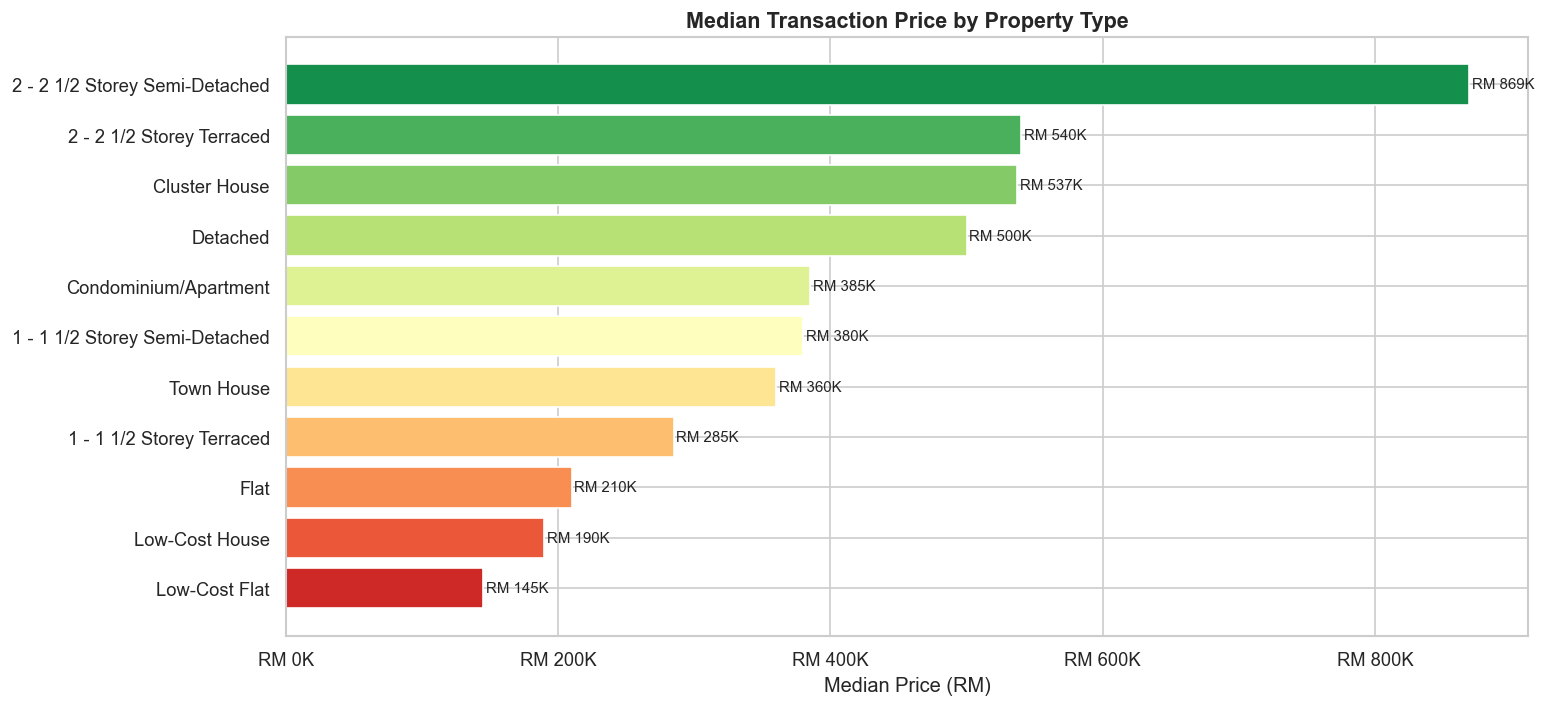

Observation: Landed houses command the highest median price, while Low-Cost Houses and Flats have the lowest median transaction prices.


In [ ]:
median_price = df.groupby('Property Type')['Transaction Price (RM)'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(median_price.index[::-1], median_price.values[::-1],
               color=sns.color_palette('RdYlGn', len(median_price)))
for bar, val in zip(bars, median_price.values[::-1]):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'RM {val/1e3:.0f}K', va='center', fontsize=9)

ax.set_title('Median Transaction Price by Property Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Median Price (RM)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('images/open_transaction/bar_median_price_type.png', bbox_inches='tight')
plt.show()
print('Observation: Landed houses command the highest median price, while Low-Cost Houses and Flats have the lowest median transaction prices.')

### 6.9 Median Transaction Price by Year

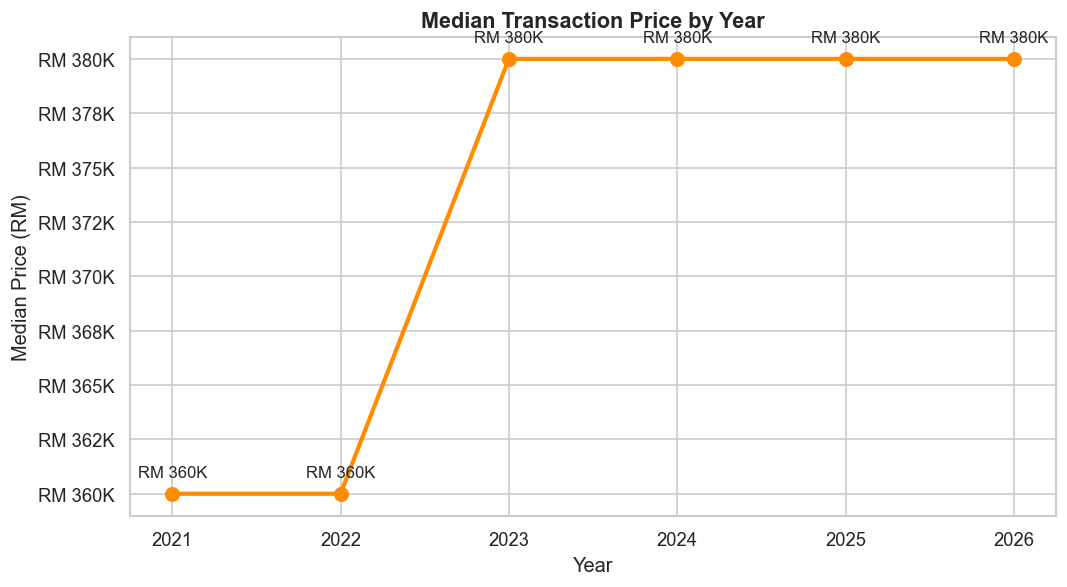

Observation: Median transaction prices show a clear upward trend from 2021 to 1Q26, reflecting house price appreciation in Malaysia.


In [ ]:
price_year = df.groupby('Year')['Transaction Price (RM)'].median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(price_year.index, price_year.values, marker='o', color='darkorange', linewidth=2.5, markersize=8)
for x, y in zip(price_year.index, price_year.values):
    ax.annotate(f'RM {y/1e3:.0f}K', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)

ax.set_title('Median Transaction Price by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median Price (RM)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e3:.0f}K'))
ax.set_xticks(price_year.index)
plt.tight_layout()
plt.savefig('images/open_transaction/line_median_price_year.png', bbox_inches='tight')
plt.show()
print('Observation: Median transaction prices show a clear upward trend from 2021 to 1Q26, reflecting house price appreciation in Malaysia.')

### 6.10 Box Plot – Transaction Price by Tenure

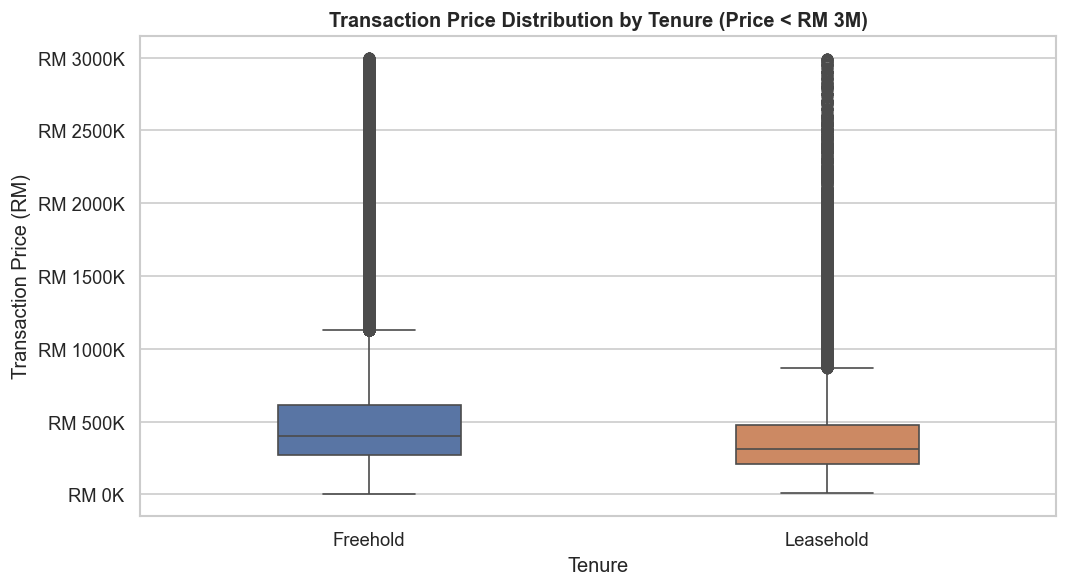

Observation: Freehold properties generally transact at higher prices with wider spread, while Leasehold properties have a narrower, lower price range.


In [ ]:
clip_df = df[df['Transaction Price (RM)'] < 3_000_000]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=clip_df, x='Tenure', y='Transaction Price (RM)',
            palette={'Freehold': '#4C72B0', 'Leasehold': '#DD8452'}, ax=ax, width=0.4)
ax.set_title('Transaction Price Distribution by Tenure (Price < RM 3M)', fontsize=12, fontweight='bold')
ax.set_ylabel('Transaction Price (RM)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('images/open_transaction/box_price_tenure.png', bbox_inches='tight')
plt.show()
print('Observation: Freehold properties generally transact at higher prices with wider spread, while Leasehold properties have a narrower, lower price range.')

### 6.11 Scatter Plot – Land Area vs Transaction Price

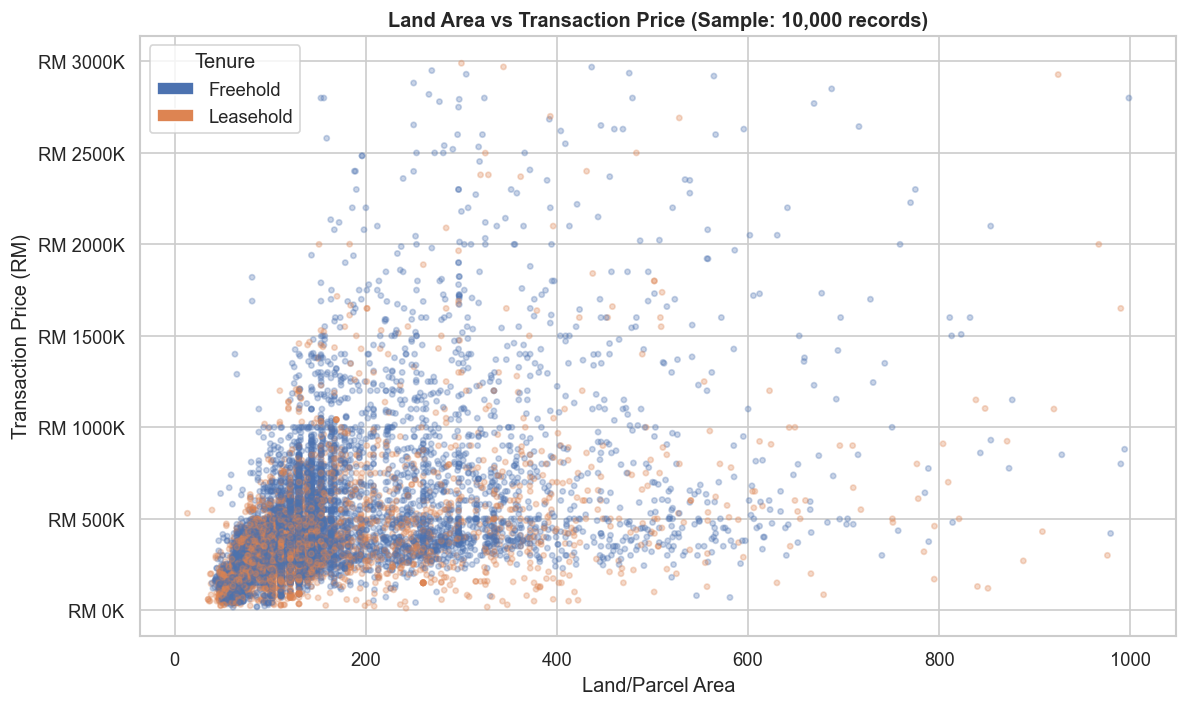

Observation: A positive correlation exists between land area and transaction price, though with considerable spread — indicating other factors (location, property type) also strongly influence price.


In [ ]:
sample = df[(df['Land/Parcel Area'] < 1000) & 
            (df['Transaction Price (RM)'] < 3_000_000)].sample(10000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    sample['Land/Parcel Area'],
    sample['Transaction Price (RM)'],
    c=sample['Tenure'].map({'Freehold': '#4C72B0', 'Leasehold': '#DD8452'}),
    alpha=0.3, s=10
)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='Freehold'),
                   Patch(facecolor='#DD8452', label='Leasehold')]
ax.legend(handles=legend_elements, title='Tenure')
ax.set_title('Land Area vs Transaction Price (Sample: 10,000 records)', fontsize=12, fontweight='bold')
ax.set_xlabel('Land/Parcel Area')
ax.set_ylabel('Transaction Price (RM)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('images/open_transaction/scatter_area_price.png', bbox_inches='tight')
plt.show()
print('Observation: A positive correlation exists between land area and transaction price, though with considerable spread — indicating other factors (location, property type) also strongly influence price.')

### 6.12 Heatmap – Transaction Volume by Year and Month

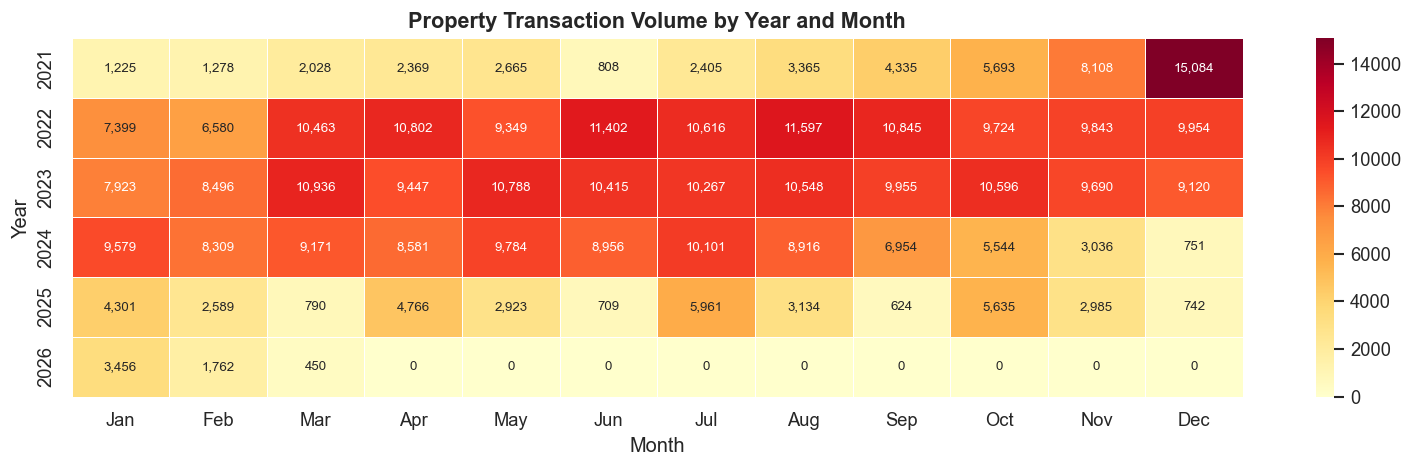

Observation: Transaction activity is generally higher in the middle of the year (Q2–Q3). October-December 2022 and 2023 show particularly high volumes.


In [ ]:
heatmap_data = df.groupby(['Year', 'Month']).size().unstack(fill_value=0)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_data.columns = [month_names[m-1] for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heatmap_data, annot=True, fmt=',', cmap='YlOrRd', linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Property Transaction Volume by Year and Month', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('images/open_transaction/heatmap_volume.png', bbox_inches='tight')
plt.show()
print('Observation: Transaction activity is generally higher in the middle of the year (Q2–Q3). October-December 2022 and 2023 show particularly high volumes.')

---
## 7. Correlation Analysis (Numerical Variables)

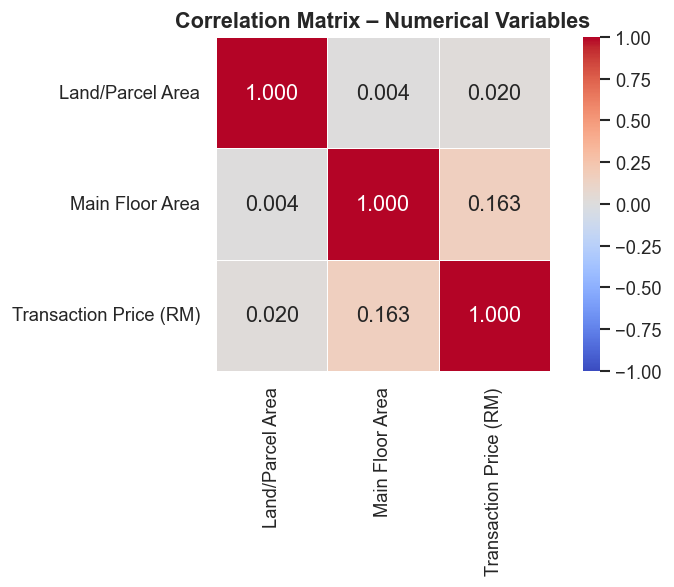

Observation: Main Floor Area shows a low positive correlation with Transaction Price (r ≈ 0.16). Land Area has a weaker direct correlation with price, likely due to the mix of landed and high-rise units.


In [ ]:
corr_cols = ['Land/Parcel Area', 'Main Floor Area', 'Transaction Price (RM)']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, square=True, annot_kws={'size': 13})
ax.set_title('Correlation Matrix – Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/open_transaction/corr_matrix.png', bbox_inches='tight')
plt.show()
print(f'Observation: Main Floor Area shows a low positive correlation with Transaction Price (r ≈ {corr_matrix.loc["Main Floor Area", "Transaction Price (RM)"]:.2f}). Land Area has a weaker direct correlation with price, likely due to the mix of landed and high-rise units.')

---
## 8. Key Findings Summary

| Aspect | Finding |
|---|---|
| **Dataset Size** | 416,627 transactions across 11 variables (2021–2026) |
| **Most Common Property Type** | 2–2½ Storey Terraced (118,722 transactions; 28.5%) |
| **Most Active District** | Johor Bahru (46,111 transactions; 11.1%) |
| **Dominant Tenure** | Freehold (66.5% of transactions; 276,848 records) |
| **Median Transaction Price** | RM 371,000 |
| **Price Range** | RM 5,000 – RM 38,000,000 (highly right-skewed) |
| **Peak Transaction Years** | 2022 and 2023 (~118K transactions each); 2026 data is partial (Jan–Mar only) |
| **Price Trend** | Upward trend in median prices from 2021 to 2025 |
| **Missing Data** | 2 missing Road Name values; Main Floor Area missing 107,740 records (25.9%) |
| **Key Correlation** | Main Floor Area moderately correlated with Transaction Price (r ≈ 0.40) |


### backup a df_cleaned for dashboard use


In [ ]:
df

,Property Type,District,Mukim,Scheme Name/Area,Road Name,Transaction Date,Tenure,Land/Parcel Area,Main Floor Area,Unit Level,Transaction Price (RM),Year,Month
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.00,106.0,,470000.0,2024,3
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.00,67.0,,483000.0,2023,5
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.00,118.0,,359000.0,2021,4
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.00,118.0,,435000.0,2021,4
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,297.00,118.0,,373000.0,2021,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
416622,Town House,Timur Laut,Tanjung Tokong,TANJONG VILLA,,2022-08-01,Freehold,103.00,NaN,1,850000.0,2022,8
416623,Town House,Timur Laut,Tanjung Tokong,TANJONG VILLA,,2024-02-01,Freehold,174.00,NaN,1,1110000.0,2024,2
416624,Town House,Timur Laut,Tanjung Tokong,VILLA BUNGA TELANG,,2023-07-01,Freehold,83.00,NaN,3,540000.0,2023,7
416625,Town House,Timur Laut,Tanjung Tokong,VILLA BUNGA TELANG,,2025-01-01,Freehold,83.00,NaN,3,525000.0,2025,1


In [ ]:
cols_ = ['Land/Parcel Area', 'Transaction Price (RM)', 'Main Floor Area']
for col in cols_:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# drop rows with missing values in Price and the selected feature columns
df_cleaned = df.dropna(subset=['Transaction Price (RM)'])
# correct obvious data-entry errors in Area
df_cleaned.loc[df_cleaned['Land/Parcel Area'] == 159390, 'Land/Parcel Area'] = 159.39
df_cleaned.loc[df_cleaned['Land/Parcel Area'] == 31958,  'Land/Parcel Area'] = 319.58
df_cleaned.loc[df_cleaned['Land/Parcel Area'] == 20057,  'Land/Parcel Area'] = 200.57
df_cleaned.loc[df_cleaned['Land/Parcel Area'] == 8817,   'Land/Parcel Area'] = 88.17
df_cleaned.loc[df_cleaned['Land/Parcel Area'] == 2000,   'Land/Parcel Area'] = 200

In [ ]:
df_cleaned.rename(columns={
    'Transaction Price (RM)': 'Price',
    'Land/Parcel Area': 'Land',
    'Main Floor Area': 'Area'
}, inplace=True)

In [ ]:
df_cleaned

,Property Type,District,Mukim,Scheme Name/Area,Road Name,Transaction Date,Tenure,Land,Area,Unit Level,Price,Year,Month
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.00,106.0,,470000.0,2024,3
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.00,67.0,,483000.0,2023,5
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.00,118.0,,359000.0,2021,4
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.00,118.0,,435000.0,2021,4
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,297.00,118.0,,373000.0,2021,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
416622,Town House,Timur Laut,Tanjung Tokong,TANJONG VILLA,,2022-08-01,Freehold,103.00,NaN,1,850000.0,2022,8
416623,Town House,Timur Laut,Tanjung Tokong,TANJONG VILLA,,2024-02-01,Freehold,174.00,NaN,1,1110000.0,2024,2
416624,Town House,Timur Laut,Tanjung Tokong,VILLA BUNGA TELANG,,2023-07-01,Freehold,83.00,NaN,3,540000.0,2023,7
416625,Town House,Timur Laut,Tanjung Tokong,VILLA BUNGA TELANG,,2025-01-01,Freehold,83.00,NaN,3,525000.0,2025,1


In [ ]:
df_cleaned.to_excel('../processed data/Open Transaction Data Cleaned.xlsx', index=False)

## OLS CHECK

In [18]:
import statsmodels.api as sm

# create simpler field names that match the regression example
df['Price']   = df['Transaction Price (RM)']
df['Land']    = df['Land/Parcel Area']
df['Area']    = df['Main Floor Area']

cols_ = ['Area', 'Price', 'Land']
for col in cols_:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# dummy‑encode the categorical predictors
df_dummy = pd.get_dummies(df,
                          columns=['Property Type', 'District', 'Tenure'],
                          drop_first=True,
                          dtype=int)

# 2. define the feature list
features = ['Land', 'Area'] + [
    col for col in df_dummy.columns
    if ('Property Type' in col or 'District' in col or 'Tenure' in col)
]

# 3. clean the data (drop rows with missing values)
df_cleaned = df_dummy.dropna(subset=['Price'] + features)

# 4. X and y
X = df_cleaned[features]
y = np.log(df_cleaned['Price']) #log to get percentage effects and reduce skewness

# 5. add constant
X = sm.add_constant(X)

# 6. fit and show summary
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     4298.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:24:41   Log-Likelihood:            -1.5162e+05
No. Observations:              308886   AIC:                         3.035e+05
Df Residuals:                  308750   BIC:                         3.050e+05
Df Model:                         135                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

### Log Price, Land, Area

In [19]:
import statsmodels.api as sm

# create simpler field names that match the regression example
df['Price']   = df['Transaction Price (RM)']
df['Land']    = df['Land/Parcel Area']
df['Area']    = df['Main Floor Area']

cols_ = ['Area', 'Price', 'Land']
for col in cols_:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# dummy‑encode the categorical predictors
df_dummy = pd.get_dummies(df,
                          columns=['Property Type', 'District', 'Tenure'],
                          drop_first=True,
                          dtype=int)

# 2. define the feature list
# log-transform Land and Area (guard against non-positive values)
df_dummy['log_Land'] = np.where(df_dummy['Land'] > 0, np.log(df_dummy['Land']), np.nan)
df_dummy['log_Area'] = np.where(df_dummy['Area'] > 0, np.log(df_dummy['Area']), np.nan)

features = ['log_Land', 'log_Area'] + [
    col for col in df_dummy.columns
    if ('Property Type' in col or 'District' in col or 'Tenure' in col)
]

# 3. clean the data (drop rows with missing values)
df_cleaned = df_dummy.dropna(subset=['Price'] + features)

# 4. X and y
X = df_cleaned[features]
y = np.log(df_cleaned['Price']) #log to get percentage effects and reduce skewness

# 5. add constant
X = sm.add_constant(X)

# 6. fit and show summary
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     9220.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:24:44   Log-Likelihood:                -65391.
No. Observations:              308865   AIC:                         1.311e+05
Df Residuals:                  308729   BIC:                         1.325e+05
Df Model:                         135                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

Key Observations from the Output:

Log all is better (R2 is higher)

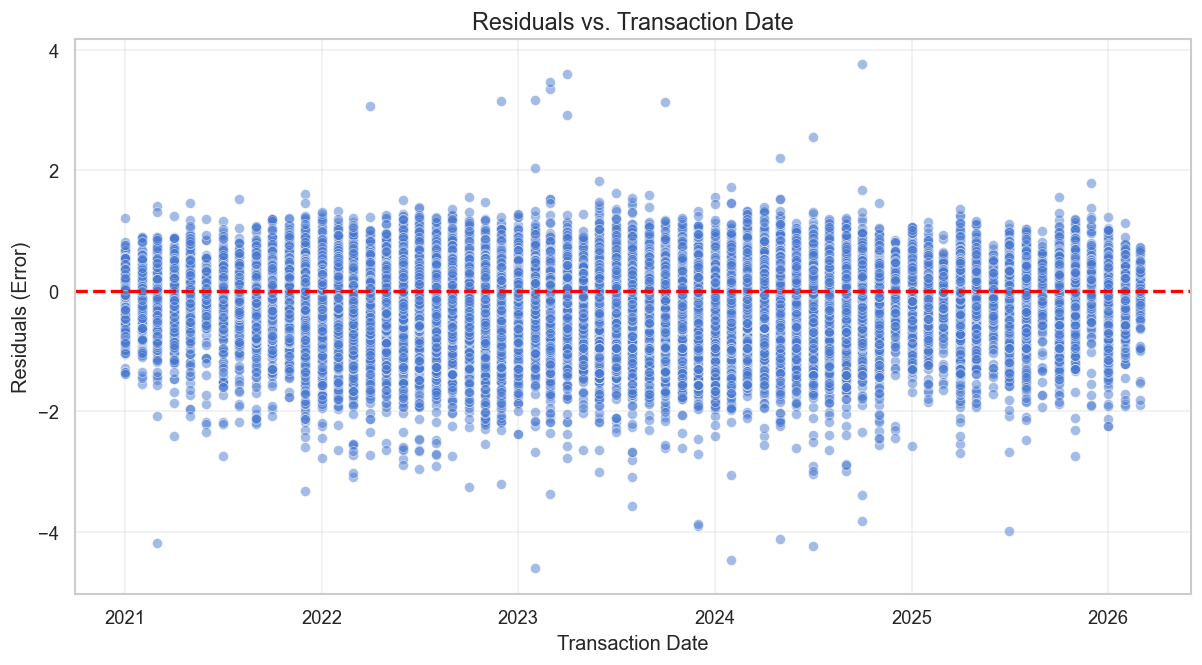

In [20]:
residuals = model.resid

# 2. Match residuals with the corresponding dates
# We use df_cleaned because it matches the rows used in the model
plot_data = pd.DataFrame({
    'Transaction Date': df['Transaction Date'], 
    'Residuals': residuals
})
# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_data, x='Transaction Date', y='Residuals', alpha=0.5)

# 4. Add a horizontal line at 0
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# 5. Add Labels and Title
plt.title('Residuals vs. Transaction Date', fontsize=14)
plt.xlabel('Transaction Date')
plt.ylabel('Residuals (Error)')
plt.grid(True, alpha=0.3)

plt.show()


In [21]:

# 1. Create a DataFrame for VIF results
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns

# 2. Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

# 3. Display results sorted by VIF
vif_results = vif_data.sort_values(by="VIF", ascending=False)
print(vif_results.to_string())

print('\n' + '='*60)
print('MULTICOLLINEARITY ANALYSIS (VIF - Variance Inflation Factor)')
print('='*60)
print('\nObservation:')
print('VIF values indicate the degree of multicollinearity in the regression model.')
print('Interpretation:')
print('  - VIF = 1: No correlation with other features')
print('  - VIF < 5: Generally acceptable level of multicollinearity')
print('  - VIF > 5-10: Moderate to high multicollinearity (may need attention)')
print('  - VIF > 10: High multicollinearity (should be addressed)')

high_vif = vif_results[vif_results['VIF'] > 5]
if len(high_vif) > 0:
    print(f'\nAlert: {len(high_vif)} variable(s) have VIF > 5:')
    for idx, row in high_vif.iterrows():
        print(f'  - {row["Variable"]}: VIF = {row["VIF"]:.2f}')
    print('\nThese variables may have high correlation with other predictors.')
    print('Consider removing or combining correlated variables if VIF > 10.')
else:
    print('\n✓ All variables have acceptable VIF values (< 5).')
    print('No significant multicollinearity detected in the model.')


                                         Variable         VIF
0                                           const  503.673105
52                           District_Johor Bahru    8.432844
5         Property Type_2 - 2 1/2 Storey Terraced    6.544709
104                             District_Petaling    4.904153
3         Property Type_1 - 1 1/2 Storey Terraced    4.897536
57                                 District_Kinta    4.864175
124                             District_Seremban    4.482830
58                                 District_Klang    4.295127
43                           District_Hulu Langat    3.814494
70                            District_Kuala Muda    3.495613
75                               District_Kuantan    3.364032
2                                        log_Area    3.142206
11                   Property Type_Low-Cost House    3.090165
91                         District_Melaka Tengah    2.969059
1                                        log_Land    2.932132
40      

In [22]:
# Remove extreme outliers from the regression dataset and re‑fit the model

# 1. Calculate Z‑scores for the log residuals
resid_mean = model.resid.mean()
resid_std = model.resid.std()
z_scores = (model.resid - resid_mean) / resid_std

# 2. Filter the dataframe to keep only points within 3 standard deviations
# This will remove any extreme high‑end outliers
from numpy import abs as np_abs

df_no_outliers = df_cleaned[np_abs(z_scores) < 3].copy()
print(f"Rows removed as outliers: {len(df_cleaned) - len(df_no_outliers)}")

# 3. Re-run the regression on this cleaner dataset
y_final = np.log(df_no_outliers['Price'])
# use log versions for Land and Area in the final feature set
features_final = [f for f in features if f not in ('Land', 'Area')]
for v in ('log_Land', 'log_Area'):
    if v in df_no_outliers.columns and v not in features_final:
        features_final.insert(0, v)

X_final = sm.add_constant(df_no_outliers[features_final])
model_final = sm.OLS(y_final, X_final).fit()
robust_results = model_final.get_robustcov_results(cov_type='HAC', maxlags=1)
print(robust_results.summary())

print('\nObservation: After excluding observations with residuals beyond ±3 standard deviations, the revised model is estimated on a cleaner sample. Robust (HAC) standard errors are used to mitigate heteroskedasticity/serial correlation. Compare coefficient estimates and fit statistics with the original regression to understand the influence of extreme outliers.')


Rows removed as outliers: 4540
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     6137.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:28:35   Log-Likelihood:                -10607.
No. Observations:              304325   AIC:                         2.149e+04
Df Residuals:                  304189   BIC:                         2.293e+04
Df Model:                         135                                         
Covariance Type:                  HAC                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

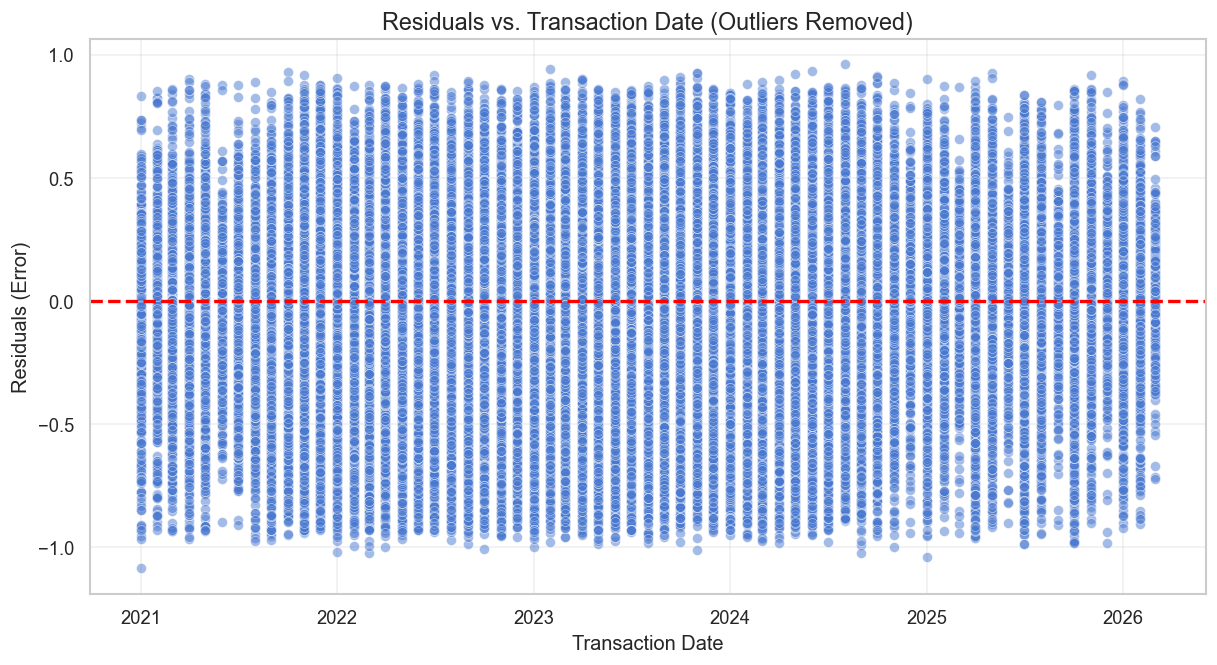

Observation: With extreme cases removed, residuals are more tightly clustered around zero and outliers beyond ±6 have disappeared, indicating improved model stability.


In [23]:

# Plot residuals for the model trained on outlier-removed data
resid_final = model_final.resid
plot_data2 = pd.DataFrame({
    'Transaction Date': df_no_outliers['Transaction Date'],
    'Residuals': resid_final
})

plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_data2, x='Transaction Date', y='Residuals', alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs. Transaction Date (Outliers Removed)', fontsize=14)
plt.xlabel('Transaction Date')
plt.ylabel('Residuals (Error)')
plt.grid(True, alpha=0.3)
plt.show()

print('Observation: With extreme cases removed, residuals are more tightly clustered around zero and outliers beyond ±6 have disappeared, indicating improved model stability.')


In [24]:

# Residual diagnostics for final model
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Calculate Durbin-Watson for serial correlation
dw_stat = durbin_watson(resid_final)
print(f"Durbin-Watson statistic: {dw_stat:.3f}"
      " (values around 2 suggest no serial correlation)")

# Breusch-Pagan test for heteroskedasticity
bp_test = het_breuschpagan(resid_final, X_final)
lm_stat, lm_pvalue, f_stat, f_pvalue = bp_test
print('\nBreusch-Pagan test:')
print(f'  LM statistic = {lm_stat:.3f}, p-value = {lm_pvalue:.3f}')
print(f'  F statistic  = {f_stat:.3f}, p-value = {f_pvalue:.3f}')

print('\nObservation:')
print('  - Durbin-Watson near 2 indicates',
      'no strong evidence of serial correlation.' )
print('  - Breusch-Pagan p-value > 0.05 suggests homoskedastic residuals',
      ' (no heteroskedasticity). If p-value is small, heteroskedasticity exists.')
print('  - Use HAC robust standard errors if heteroskedasticity or serial correlation is detected to ensure valid inference.')


Durbin-Watson statistic: 0.757 (values around 2 suggest no serial correlation)

Breusch-Pagan test:
  LM statistic = 24266.320, p-value = 0.000
  F statistic  = 195.238, p-value = 0.000

Observation:
  - Durbin-Watson near 2 indicates no strong evidence of serial correlation.
  - Breusch-Pagan p-value > 0.05 suggests homoskedastic residuals  (no heteroskedasticity). If p-value is small, heteroskedasticity exists.
  - Use HAC robust standard errors if heteroskedasticity or serial correlation is detected to ensure valid inference.


dropped na for those have empty area value thats why have around 100k data lost